# ERA5 Data Download and Visualization

This notebook demonstrates how to:
1. Download ERA5 reanalysis data (e.g., 500 mb Geopotential height)
2. Download 850 hPa u and v wind components
3. Process and visualize the data over a specific region with wind vectors overlaid

## Install Required Packages
Run this cell if packages are not already installed.

In [1]:
# Uncomment to install required packages
# !pip install cdsapi xarray netCDF4 matplotlib cartopy

## Import Required Libraries

In [2]:
import cdsapi
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from datetime import datetime
%config InlineBackend.figure_format='retina'

In [3]:
loc_Humboldt = [-124.5907, 40.97]
loc_Morro    = [-121.8581, 35.7107]

In [4]:
events = [
    ('(a) AR Humboldt',         '2020-12-21 00:00:00', '2020-12-24 00:00:00', 'AR_Humboldt'),
    ('(b) AR Morro Bay',        '2020-12-14 00:00:00', '2020-12-16 00:00:00', 'AR_Morro'),
    ('(c) Downslope Humboldt',  '2020-11-25 00:00:00', '2020-11-28 00:00:00', 'Downslope_Humboldt'),
    ('(d) Downslope Morro Bay', '2020-11-16 00:00:00', '2020-11-18 00:00:00', 'Downslope_Morro'),
    ('(e) LLJ Humboldt',        '2021-07-21 00:00:00', '2021-07-24 00:00:00', 'LLJ_Humboldt'),    
    ('(f) LLJ Morro Bay',       '2021-05-07 00:00:00', '2021-05-09 00:00:00', 'LLJ_Morro'),
]

## Configure CDS API

You need to register at https://cds.climate.copernicus.eu and obtain your API key.
Create a file `~/.cdsapirc` with your credentials:
```
url: https://cds.climate.copernicus.eu/api/v2
key: YOUR_UID:YOUR_API_KEY
```

In [5]:
# Initialize CDS API client
c = cdsapi.Client()

## Download ERA5 Data

Downloading 500 mb Geopotential height and 850 hPa u/v wind components over a specific region.

In [ ]:
import pandas as pd
def download_era5(start, end, event_name):
    # Define download parameters
    _start = pd.Timestamp(start).strftime('%Y%m%d')
    _end   = pd.Timestamp(end).strftime('%Y%m%d')
    output_file_z500 = f'era5_z500_data.{_start}_{_end}.{event_name}.nc'
    output_file_winds = f'era5_850_winds_data.{_start}_{_end}.{event_name}.nc'

    # Define region (North, West, South, East)
    # Example: North America region
    region = [55, -140, 25, -100]  # [N, W, S, E]

    period = pd.date_range(start, end, freq='1h')
    years  = np.unique(period.strftime('%Y')).tolist()
    months = np.unique(period.strftime('%m')).tolist()
    days   = np.unique(period.strftime('%d')).tolist()
    hours  = [f"{int(h):02d}:00" for h in np.unique(period.strftime('%H'))]

    print(f"Downloading data for {event_name}:")
    print(f"  Period: {start} to {end}")
    print(f"  Years: {years}, Months: {months}, Days: {days}")
    print(f"  Hours: {hours}")

    # Download 500 mb geopotential
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            'variable': 'geopotential',
            'pressure_level': '500',
            'year': years,
            'month': months,
            'day': days,
            'time': hours,
            'area': region,  # [N, W, S, E]
            'format': 'netcdf',
        },
        output_file_z500
    )

    print(f"Z500 data downloaded successfully to {output_file_z500}")

    # Download 850 hPa u and v wind components
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            'variable': ['u_component_of_wind', 'v_component_of_wind'],
            'pressure_level': '850',
            'year': years,
            'month': months,
            'day': days,
            'time': hours,
            'area': region,  # [N, W, S, E]
            'format': 'netcdf',
        },
        output_file_winds
    )

    print(f"850 hPa winds data downloaded successfully to {output_file_winds}")
    print("-" * 60)
    
    return output_file_z500, output_file_winds

# Download data for all events
downloaded_files = {}
for event in events:
    title, start, end, event_name = event
    z500_file, winds_file = download_era5(start, end, event_name)
    downloaded_files[event_name] = {'z500': z500_file, 'winds': winds_file}
    
print("\nAll downloads completed!")
print(f"Downloaded {len(downloaded_files)} events")

  Period: 2020-12-21 00:00:00 to 2020-12-24 00:00:00
  Years: ['2020'], Months: ['12'], Days: ['21', '22', '23', '24']
  Hours: ['00:00', '01:00', '02:00', '03:00', '04:00', '05:00', '06:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']


2026-07-13 07:08:27,791 INFO Request ID is 1e7b9cf5-e78b-4c2b-8207-bb5cdac5fac3
2026-07-13 07:08:28,183 INFO status has been updated to accepted


2026-07-13 07:08:42,514 INFO status has been updated to running
2026-07-13 07:09:01,872 INFO status has been updated to successful


35103f20d5b7ed38aea0164b200ec41c.nc:   0%|          | 0.00/2.61M [00:00<?, ?B/s]

Z500 data downloaded successfully to era5_z500_data.20201221_20201224.AR_Humboldt.nc


...

850 hPa winds data downloaded successfully to era5_850_winds_data.20201221_20201224.AR_Humboldt.nc
------------------------------------------------------------
  Period: 2020-12-14 00:00:00 to 2020-12-16 00:00:00
  Years: ['2020'], Months: ['12'], Days: ['14', '15', '16']
  Hours: ['00:00', '01:00', '02:00', '03:00', '04:00', '05:00', '06:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']


2026-07-13 07:10:03,373 INFO Request ID is 4e481f5b-992a-4c78-9fd5-6a6132ada58a
2026-07-13 07:10:03,581 INFO status has been updated to accepted
2026-07-13 07:10:22,203 INFO status has been updated to running
2026-07-13 07:10:41,580 INFO status has been updated to successful


3b480c7c65b24ffa9136859fa51de351.nc:   0%|          | 0.00/1.93M [00:00<?, ?B/s]

Z500 data downloaded successfully to era5_z500_data.20201214_20201216.AR_Morro.nc


2026-07-13 07:10:45,237 INFO Request ID is a68c1e32-1ffb-40a4-b710-6eb6e927f3f7
2026-07-13 07:10:45,424 INFO status has been updated to accepted
2026-07-13 07:10:59,623 INFO status has been updated to running


## Load and Process Data

In [ ]:
# Load the downloaded data
ds = {}
for event in events:
    title, start, end, event_name = event
    _start = pd.Timestamp(start).strftime('%Y%m%d')
    _end   = pd.Timestamp(end).strftime('%Y%m%d')
    output_file_z500 = f'era5_z500_data.{_start}_{_end}.{event_name}.nc'
    output_file_winds = f'era5_850_winds_data.{_start}_{_end}.{event_name}.nc'        
    xds_z500 = xr.open_dataset(output_file_z500)
    xds_wind = xr.open_dataset(output_file_winds)

    # Convert geopotential to geopotential height (divide by 9.80665)
    xds_z500['z500'] = xds_z500['z'] / 9.80665

    xds = xr.merge([xds_z500, xds_wind])
    ds[event_name] = xds

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print(ds)

{'AR_Humboldt': <xarray.Dataset> Size: 60MB
Dimensions:         (valid_time: 96, pressure_level: 2, latitude: 121,
                     longitude: 161)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 768B 2020-12-21 ... 2020-12-2...
  * pressure_level  (pressure_level) float64 16B 500.0 850.0
  * latitude        (latitude) float64 968B 55.0 54.75 54.5 ... 25.5 25.25 25.0
  * longitude       (longitude) float64 1kB -140.0 -139.8 ... -100.2 -100.0
    number          int64 8B 0
    expver          (valid_time) <U4 2kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    z500            (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreD

## Visualize the Data with Wind Vectors

Create a 3x2 subplot layout showing all events.

In [ ]:
plot_period = {
    'AR_Humboldt': ('2020-12-21 00:00:00', '2020-12-22 00:00:00'),
    'AR_Morro':    ('2020-12-14 00:00:00', '2020-12-15 00:00:00'),
    'Downslope_Humboldt': ('2020-11-26 00:00:00', '2020-11-28 00:00:00'),
    'Downslope_Morro': ('2020-11-16 00:00:00', '2020-11-16 12:00:00'),
    'LLJ_Humboldt': ('2021-07-21 00:00:00', '2021-07-24 00:00:00'),
    'LLJ_Morro': ('2021-05-07 00:00:00', '2021-05-09 00:00:00'),
}

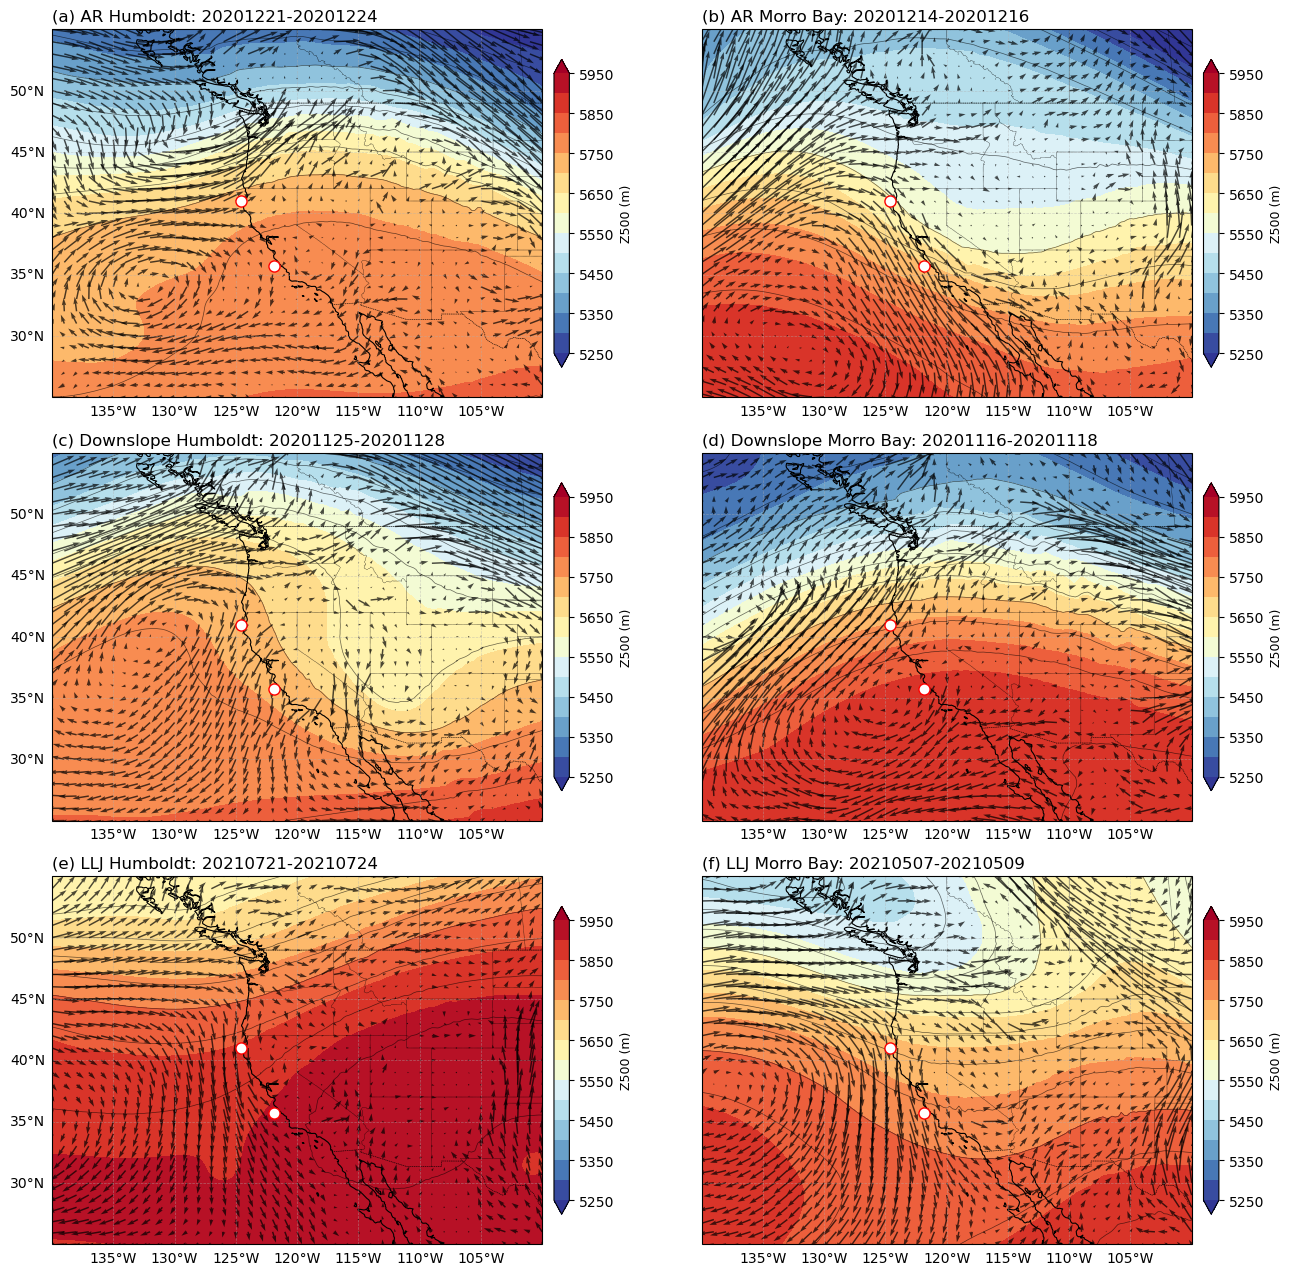

In [ ]:
# Create subplot figure
fig, axs = plt.subplots(3, 2, figsize=(16, 16), 
                        subplot_kw={'projection': ccrs.PlateCarree()})
plt.subplots_adjust(hspace=0.1, wspace=0.1)

axs = axs.ravel()

skip = 4  # Subsample wind vectors

# Plot each event
for i, event in enumerate(events):
    title, start, end, event_name = event
    ax = axs[i]
    
    # Get the dataset for this event
    xds = ds[event_name]
    
    # Select a specific time step (middle of the event)
    data_z500 = xds['z500'].sel(valid_time=slice(*plot_period[event_name])).mean('valid_time').sel(pressure_level=500)
    data_u = xds['u'].sel(valid_time=slice(*plot_period[event_name])).mean('valid_time').sel(pressure_level=850)
    data_v = xds['v'].sel(valid_time=slice(*plot_period[event_name])).mean('valid_time').sel(pressure_level=850)

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.2, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.2, facecolor='lightblue')

    # Plot the geopotential height data
    contour = ax.contourf(
        xds.longitude, 
        xds.latitude, 
        data_z500.squeeze(),
        levels=[5250, 5300, 5350, 5400, 5450, 5500, 5550, 5600, 5650, 5700, 5750, 5800, 5850, 5900, 5950],
        cmap='RdYlBu_r',
        transform=ccrs.PlateCarree(),
        extend='both'
    )

    # Add contour lines
    contour_lines = ax.contour(
        xds.longitude,
        xds.latitude,
        data_z500.squeeze(),
        levels=10,
        colors='black',
        linewidths=0.5,
        alpha=0.6,
        transform=ccrs.PlateCarree()
    )

    # Overlay 850 hPa wind vectors
    ax.quiver(
        xds.longitude[::skip],
        xds.latitude[::skip],
        data_u.squeeze()[::skip, ::skip],
        data_v.squeeze()[::skip, ::skip],
        transform=ccrs.PlateCarree(),
        scale=200,
        width=0.003,
        color='black',
        alpha=0.7
    )

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i % 2 == 1:  # Right column
        gl.left_labels = False

    # Set title
    # time_str = xds.valid_time[time_idx].dt.strftime("%Y-%m-%d %H:%M").values
    time_str = pd.Timestamp(start).strftime('%Y%m%d') + "-" + pd.Timestamp(end).strftime('%Y%m%d')
    ax.set_title(f'{title}: {time_str}', fontsize=12, loc='left')
    
    # Add colorbar
    cbar = plt.colorbar(contour, ax=ax, orientation='vertical', 
                       pad=0.02, shrink=0.8, aspect=20)
    cbar.set_label('Z500 (m)', fontsize=9)

    ax.plot(loc_Humboldt[0], loc_Humboldt[1], 'o', color='r', mfc='w',markersize=8, transform=ccrs.PlateCarree(), zorder=10)
    ax.plot(loc_Morro[0], loc_Morro[1], 'o', color='r', mfc='w',markersize=8, transform=ccrs.PlateCarree(), zorder=10)

plt.savefig('era5_all_events.png', dpi=300, bbox_inches='tight')
plt.show()